In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

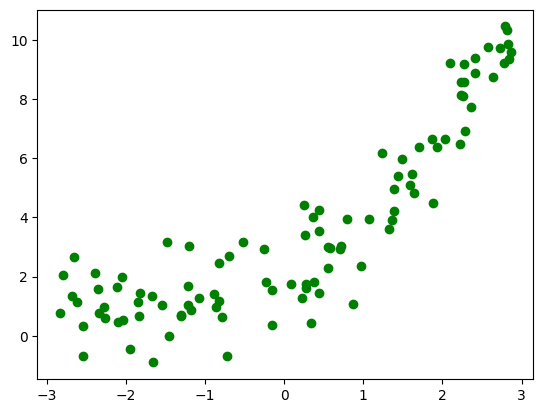

In [11]:
x=6*np.random.rand(100,1) - 3
y=0.5 * x **2 + 1.5*x + 2 +np.random.randn(100,1) 
plt.scatter(x,y,color='g')

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [14]:
y_pred=regression.predict(x_test)

In [16]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.6997493076811929


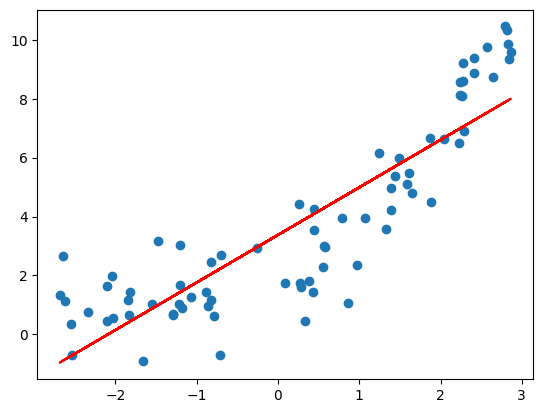

In [18]:
plt.plot(x_train,regression.predict(x_train),color='r')
plt.scatter(x_train,y_train)


In [20]:
from sklearn.preprocessing import PolynomialFeatures

In [22]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [25]:
regression.fit(x_train_poly,y_train)
y_predict=regression.predict(x_test_poly)
score1=r2_score(y_test,y_predict)
print(score1)

0.9059412487653994


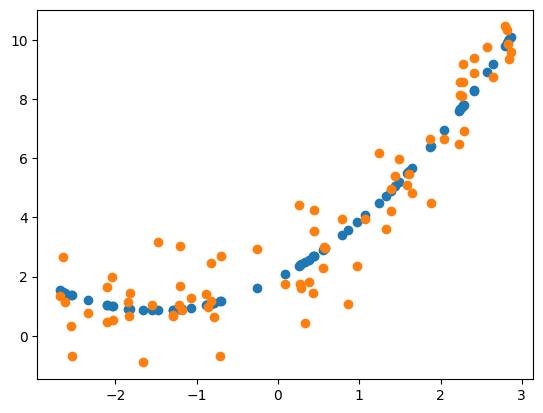

In [34]:
plt.scatter(x_train,regression.predict(x_train_poly))
plt.scatter(x_train,y_train)


In [35]:
from sklearn.pipeline import Pipeline

In [42]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(x_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

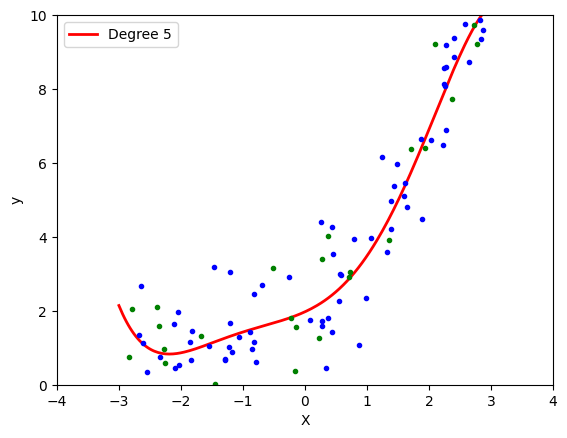

In [44]:
poly_regression(5)